In [1]:
!pip install imbalanced-learn

SCENARIO 1 – BAGGING (Diabetes)

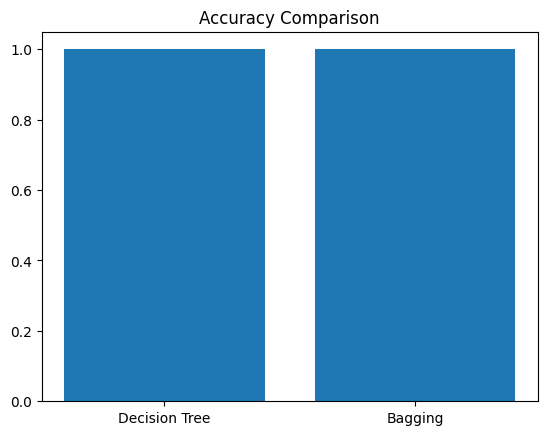

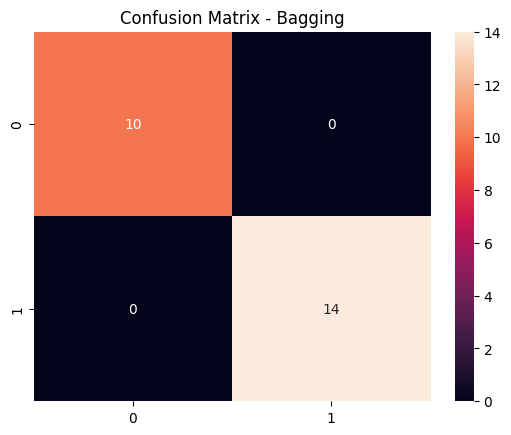

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('diabetes_bagging.csv')

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

# Bar Graph
plt.bar(['Decision Tree','Bagging'], [acc_dt, acc_bag])
plt.title('Accuracy Comparison')
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True)
plt.title('Confusion Matrix - Bagging')
plt.show()

SCENARIO 2 – BOOSTING (Churn)

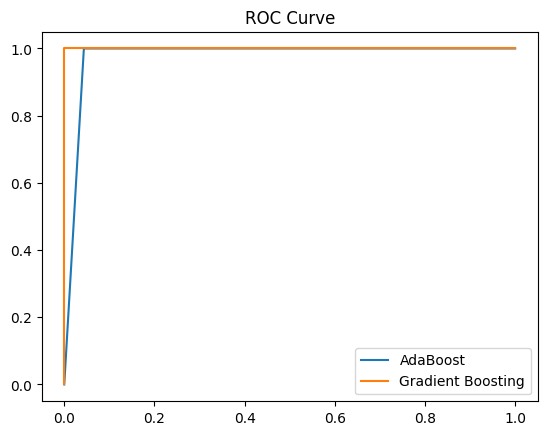

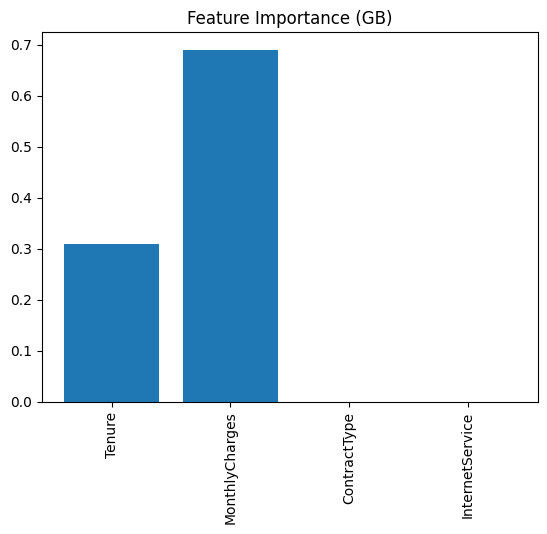

In [3]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('churn_boosting.csv')

# Encoding
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# ROC Curve
for model, name in [(ada,'AdaBoost'), (gb,'Gradient Boosting')]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title('ROC Curve')
plt.show()

# Feature Importance
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=90)
plt.title('Feature Importance (GB)')
plt.show()

SCENARIO 3 – RANDOM FOREST (Income)

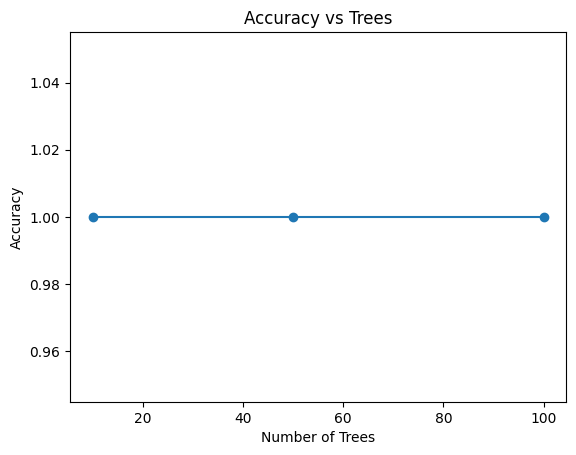

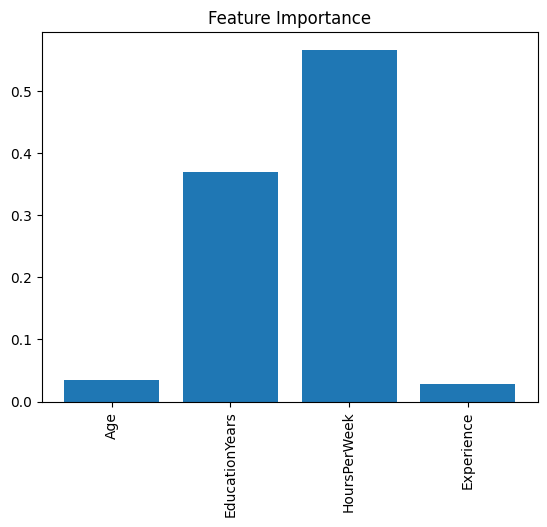

In [4]:
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('income_random_forest.csv')

for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

trees = [10, 50, 100]
acc = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(trees, acc, marker='o')
plt.title('Accuracy vs Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

SCENARIO 4 – STACKING (Heart Disease)

Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')
Detected target column: HeartDisease
Logistic Regression Accuracy: 0.8333333333333334
SVM Accuracy: 0.8333333333333334
Decision Tree Accuracy: 0.9583333333333334
Stacking Accuracy: 0.9583333333333334


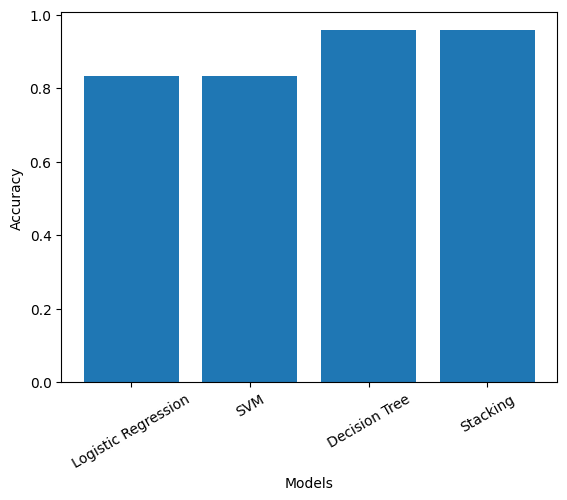

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

df = pd.read_csv('heart_stacking.csv')

print(df.columns)

df = df.dropna()

for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

target_col = df.columns[-1]
print("Detected target column:", target_col)

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

estimators = [
    ('lr', lr),
    ('svm', svm),
    ('dt', dt)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Decision Tree": dt,
    "Stacking": stack
}

accuracies = []
names = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", acc)
    accuracies.append(acc)
    names.append(name)

plt.figure()
plt.bar(names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

SCENARIO 5 – SMOTE (Fraud Detection)

Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')
Detected target column: Fraud
Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64
After SMOTE:
 Fraud
0    88
1    88
Name: count, dtype: int64


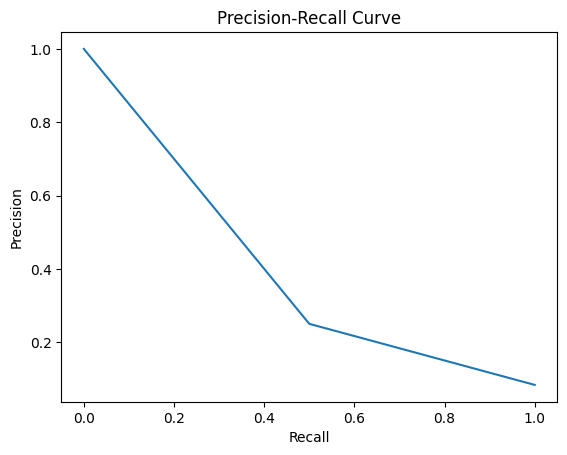

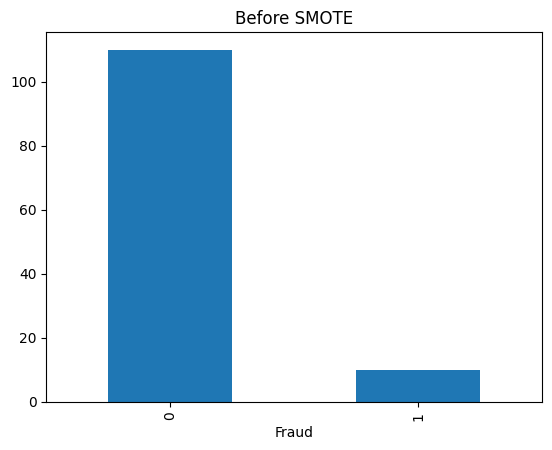

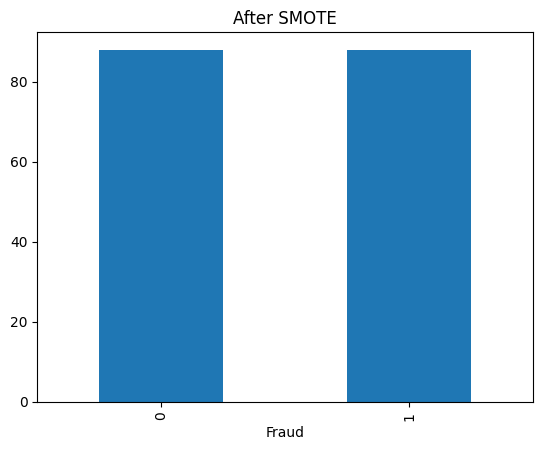

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve

from imblearn.over_sampling import SMOTE

df = pd.read_csv('fraud_smote.csv')

print(df.columns)

df = df.dropna()

target_col = df.columns[-1]
print("Detected target column:", target_col)

X = df.drop(target_col, axis=1)
y = df[target_col]

print("Before SMOTE:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

model_smote = DecisionTreeClassifier()
model_smote.fit(X_res, y_res)

y_prob = model_smote.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

plt.figure()
pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.show()